## **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

## **Import Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/ML_DL/Dataset/diet_recommendations_dataset.csv")
df

Mounted at /content/drive


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P0996,18,Male,72.1,160,28.2,Obesity,Moderate,Active,2639,152.6,166,125.1,Low_Sugar,NaN,Mexican,4.4,55.0,3.6,Balanced
996,P0997,35,Female,104.0,171,35.6,Hypertension,Moderate,Moderate,1661,172.2,126,78.6,Low_Sodium,NaN,Chinese,7.3,88.8,2.9,Low_Sodium
997,P0998,49,Female,56.0,182,16.9,Obesity,Severe,Moderate,3102,228.0,148,70.2,Low_Sugar,NaN,Indian,8.9,68.6,4.8,Balanced
998,P0999,64,Male,66.6,185,19.5,Diabetes,Severe,Active,3235,170.1,177,138.0,Low_Sugar,Gluten,Indian,6.7,52.0,0.1,Low_Carb


## **Dataset**

In [ ]:
df

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P0996,18,Male,72.1,160,28.2,Obesity,Moderate,Active,2639,152.6,166,125.1,Low_Sugar,NaN,Mexican,4.4,55.0,3.6,Balanced
996,P0997,35,Female,104.0,171,35.6,Hypertension,Moderate,Moderate,1661,172.2,126,78.6,Low_Sodium,NaN,Chinese,7.3,88.8,2.9,Low_Sodium
997,P0998,49,Female,56.0,182,16.9,Obesity,Severe,Moderate,3102,228.0,148,70.2,Low_Sugar,NaN,Indian,8.9,68.6,4.8,Balanced
998,P0999,64,Male,66.6,185,19.5,Diabetes,Severe,Active,3235,170.1,177,138.0,Low_Sugar,Gluten,Indian,6.7,52.0,0.1,Low_Carb


## **Label Encoding**

In [ ]:
disease_encoder = LabelEncoder()
activity_encoder = LabelEncoder()
diet_encoder = LabelEncoder()

df["Disease_Type"] = disease_encoder.fit_transform(df["Disease_Type"])
df["Physical_Activity_Level"] = activity_encoder.fit_transform(df["Physical_Activity_Level"])
df["Diet_Recommendation"] = diet_encoder.fit_transform(df["Diet_Recommendation"])

## **Classes**

In [ ]:
print(disease_encoder.classes_)
print(activity_encoder.classes_)
print(diet_encoder.classes_)

['Diabetes' 'Hypertension' 'Obesity' nan]
['Active' 'Moderate' 'Sedentary']
['Balanced' 'Low_Carb' 'Low_Sodium']


## **Features and Targets**

In [ ]:
X = df[["Age","BMI","Disease_Type","Physical_Activity_Level"]]

y = df["Diet_Recommendation"]

## **Splitting**

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## **Models**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}

accuracy = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy[name] = accuracy_score(y_test, pred)*100

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:01:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## **Model Comparison**

In [ ]:
comparison = pd.DataFrame({
    "Model":accuracy.keys(),
    "Accuracy":accuracy.values()
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,100.0
1,Decision Tree,100.0
2,Random Forest,100.0
4,XGBoost,100.0
3,KNN,52.0


## **Model vs Accuracy**

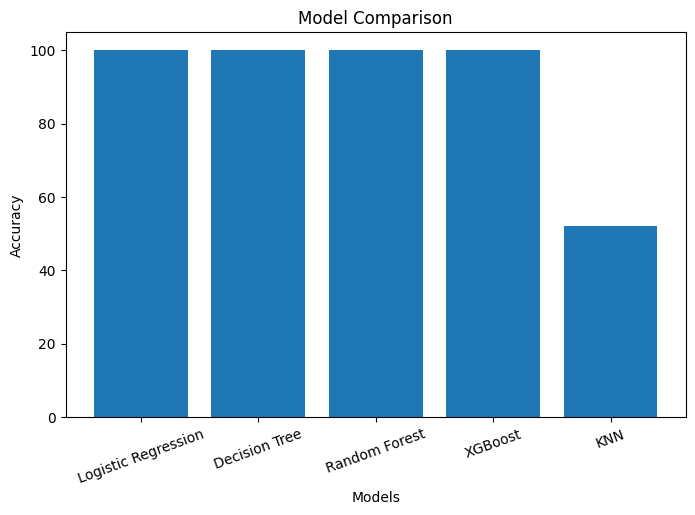

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"],comparison["Accuracy"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

## **Best Model Identification**

In [ ]:
best_model_name = comparison.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model :",best_model_name)

Best Model : Logistic Regression


# **Output**

In [ ]:

age = int(input("Enter Age: "))
bmi = float(input("Enter BMI: "))

print("\nAvailable Diseases")
print(list(disease_encoder.classes_))

disease = input("Enter Disease: ")

print("\nAvailable Activity Levels")
print(list(activity_encoder.classes_))

activity = input("Enter Activity Level: ")

disease = disease_encoder.transform([disease])[0]
activity = activity_encoder.transform([activity])[0]

sample = [[age,bmi,disease,activity]]

prediction = best_model.predict(sample)

diet = diet_encoder.inverse_transform(prediction)

print("\n========== RESULT ==========")

print("Age :",age)
print("BMI :",bmi)
print("Disease :",disease_encoder.inverse_transform([disease])[0])
print("Activity :",activity_encoder.inverse_transform([activity])[0])

print("\nRecommended Diet :",diet[0])

Enter Age: 48
Enter BMI: 30.5

Available Diseases
['Diabetes', 'Hypertension', 'Obesity', nan]
Enter Disease: Diabetes

Available Activity Levels
['Active', 'Moderate', 'Sedentary']
Enter Activity Level: Sedentary

========== RESULT ==========
Age : 48
BMI : 30.5
Disease : Diabetes
Activity : Sedentary

Recommended Diet : Low_Carb


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## **Pickling**

In [ ]:
import pickle

saved_objects = {
    "model": best_model,
    "disease_encoder": disease_encoder,
    "activity_encoder": activity_encoder,
    "diet_encoder": diet_encoder
}

with open("diet_recommendation_system.pkl", "wb") as file:
    pickle.dump(saved_objects, file)

print("Saved Successfully")

Saved Successfully
